
Loading MRI volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

MRI Loaded Successfully!

MRI Shape = (181, 217, 181)

Datatype = uint8

Minimum = 0
Maximum = 255

After Normalization:
Minimum = 0.0
Maximum = 1.0


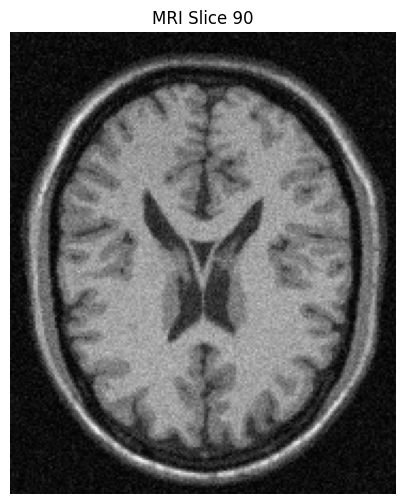


MRI Ready For 3D U-Net!


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FILE PATH
# ============================================================

MRI_PATH = "t1_icbm_normal_1mm_pn7_rf20.rawb"

# ============================================================
# MRI DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD MRI
# ============================================================

print("\nLoading MRI volume...")

mri_volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = DEPTH * HEIGHT * WIDTH

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", mri_volume.size)

if mri_volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {mri_volume.size}"
    )

# ============================================================
# RESHAPE
# ============================================================

mri_volume = mri_volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Loaded Successfully!")

print("\nMRI Shape =", mri_volume.shape)

print("\nDatatype =", mri_volume.dtype)

# ============================================================
# CHECK RANGE
# ============================================================

print("\nMinimum =", np.min(mri_volume))

print("Maximum =", np.max(mri_volume))

# ============================================================
# NORMALIZE
# ============================================================

mri_volume = mri_volume.astype(np.float32)

mri_volume = mri_volume / 255.0

print("\nAfter Normalization:")

print("Minimum =", np.min(mri_volume))

print("Maximum =", np.max(mri_volume))

# ============================================================
# DISPLAY SLICE
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    mri_volume[slice_index],
    cmap='gray'
)

plt.title(f"MRI Slice {slice_index}")

plt.axis("off")

plt.show()

print("\nMRI Ready For 3D U-Net!")


Loading Ground Truth Volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

Ground Truth Loaded Successfully!

Ground Truth Shape = (181, 217, 181)

Datatype = uint8

Unique Labels Found:
[0 1 2 3 4 5 6 7 8 9]


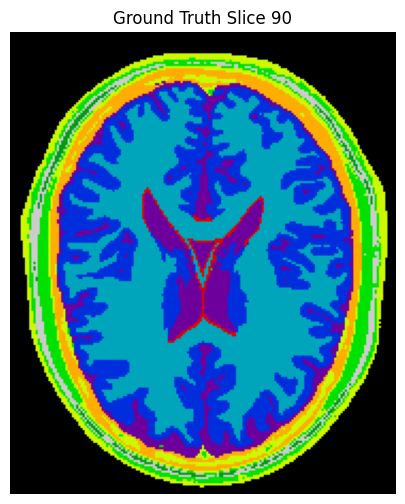


Ground Truth Ready For Training!


In [6]:
#Load Segmentation Label
# ============================================================
# LOAD SEGMENTATION LABEL VOLUME
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# GROUND TRUTH FILE
# ============================================================

GT_PATH = "phantom_1.0mm_normal_crisp.rawb"

# ============================================================
# GROUND TRUTH DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD GROUND TRUTH
# ============================================================

print("\nLoading Ground Truth Volume...")

gt_volume = np.fromfile(
    GT_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = DEPTH * HEIGHT * WIDTH

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", gt_volume.size)

if gt_volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {gt_volume.size}"
    )

# ============================================================
# RESHAPE INTO 3D
# ============================================================

gt_volume = gt_volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nGround Truth Loaded Successfully!")

print("\nGround Truth Shape =", gt_volume.shape)

print("\nDatatype =", gt_volume.dtype)

# ============================================================
# CHECK LABEL VALUES
# ============================================================

unique_labels = np.unique(gt_volume)

print("\nUnique Labels Found:")

print(unique_labels)

# ============================================================
# DISPLAY MIDDLE SLICE
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    gt_volume[slice_index],
    cmap='nipy_spectral'
)

plt.title(f"Ground Truth Slice {slice_index}")

plt.axis("off")

plt.show()

# ============================================================
# READY
# ============================================================

print("\nGround Truth Ready For Training!")


Loading MRI Volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

MRI Shape = (181, 217, 181)

Converting To Float32...

Scaling Intensities To [0,1]...

Applying Z-Score Normalization...

Mean = 0.19803284
Std = 0.1889878

Z-Score Normalization Completed!

Final Intensity Statistics
Minimum = -1.02711
Maximum = 4.243486
Mean = 3.792363e-07
Std = 1.0000002


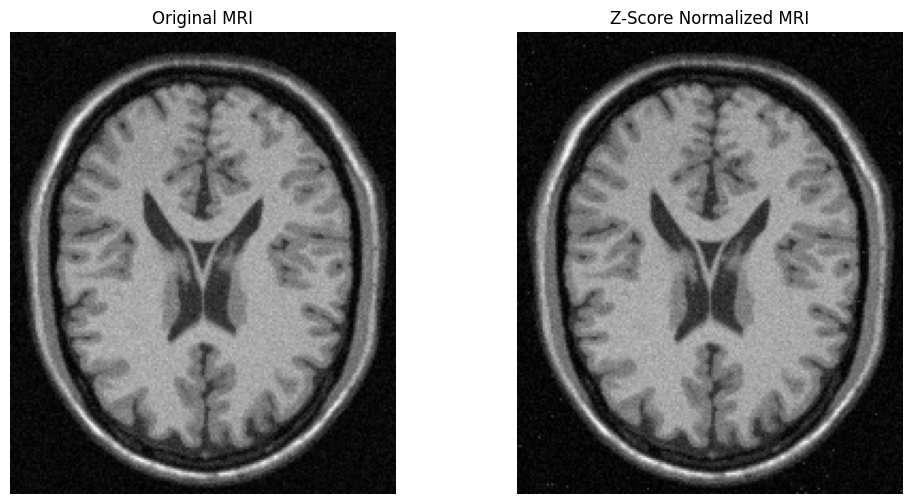


Preprocessing Completed!

Operations Applied:
- Float32 conversion
- Intensity scaling
- Z-score normalization


MRI Ready For 3D U-Net!


In [7]:
# ============================================================
# PREPROCESSING + Z-SCORE NORMALIZATION ONLY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MRI FILE
# ============================================================

MRI_PATH = "t1_icbm_normal_1mm_pn5_rf20.rawb"

# ============================================================
# MRI DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD MRI
# ============================================================

print("\nLoading MRI Volume...")

volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = (
    DEPTH *
    HEIGHT *
    WIDTH
)

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", volume.size)

if volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {volume.size}"
    )

# ============================================================
# RESHAPE
# ============================================================

volume = volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Shape =", volume.shape)

# ============================================================
# CONVERT TO FLOAT32
# ============================================================

print("\nConverting To Float32...")

volume = volume.astype(np.float32)

# ============================================================
# SCALE TO [0,1]
# ============================================================

print("\nScaling Intensities To [0,1]...")

volume = volume / 255.0

# ============================================================
# Z-SCORE NORMALIZATION ONLY
# ============================================================

print("\nApplying Z-Score Normalization...")

# ------------------------------------------------------------
# USE NON-ZERO VOXELS ONLY
# ------------------------------------------------------------

brain_voxels = volume[
    volume > 0
]

mean = np.mean(
    brain_voxels
)

std = np.std(
    brain_voxels
)

print("\nMean =", mean)

print("Std =", std)

# ------------------------------------------------------------
# Z-SCORE FORMULA
# ------------------------------------------------------------

normalized_volume = (
    volume - mean
) / (
    std + 1e-8
)

# ------------------------------------------------------------
# KEEP BACKGROUND BLACK
# ------------------------------------------------------------

normalized_volume[
    volume == 0
] = 0

print("\nZ-Score Normalization Completed!")

# ============================================================
# CHECK FINAL RANGE
# ============================================================

print("\nFinal Intensity Statistics")

print("Minimum =",
      np.min(normalized_volume))

print("Maximum =",
      np.max(normalized_volume))

print("Mean =",
      np.mean(
          normalized_volume[
              volume > 0
          ]
      ))

print("Std =",
      np.std(
          normalized_volume[
              volume > 0
          ]
      ))

# ============================================================
# VISUALIZATION
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(12,6))

# ------------------------------------------------------------
# ORIGINAL MRI
# ------------------------------------------------------------

plt.subplot(1,2,1)

plt.imshow(
    volume[slice_index],
    cmap='gray'
)

plt.title("Original MRI")

plt.axis("off")

# ------------------------------------------------------------
# NORMALIZED MRI
# ------------------------------------------------------------

plt.subplot(1,2,2)

plt.imshow(
    normalized_volume[slice_index],
    cmap='gray'
)

plt.title("Z-Score Normalized MRI")

plt.axis("off")

plt.show()

# ============================================================
# FINAL INFORMATION
# ============================================================

print("\nPreprocessing Completed!")

print("""
Operations Applied:
- Float32 conversion
- Intensity scaling
- Z-score normalization
""")

print("\nMRI Ready For 3D U-Net!")


MRI Shape = (181, 217, 181)
Ground Truth Shape = (181, 217, 181)

Unique Labels After Cleanup
[0 1 2 3]

Extracting 3D Patches...

Total Valid Patches = 150

Image Patch Shape = (150, 32, 32, 32, 1)
Mask Patch Shape = (150, 32, 32, 32)

One Patch Shape = (32, 32, 32, 1)

Patch Intensity Range
Minimum = 0.0
Maximum = 0.9764706

Unique Labels In Mask Patches
[0 1 2 3]

Selecting Best Brain Patch...
Best Patch Index = 108


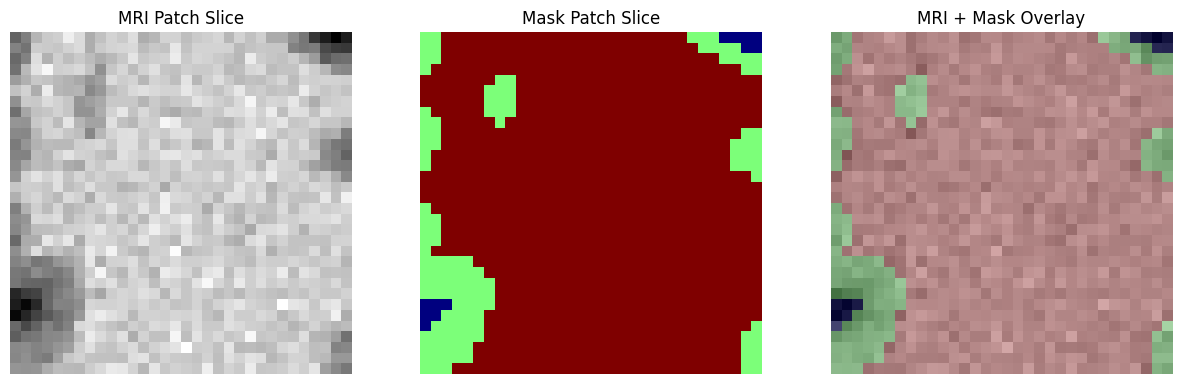


Patch Extraction Completed Successfully!

Ready For 3D U-Net Dataset Creation!

Final Dataset Information
Total Image Patches = 150
Total Mask Patches = 150
Patch Size = 32
Stride = 32


In [8]:
#Patch Extraction
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PATCH PARAMETERS
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nMRI Shape =", volume.shape)

print("Ground Truth Shape =", gt_volume.shape)

# ============================================================
# KEEP ONLY 3 CLASSES
# ============================================================

gt_volume[gt_volume > 3] = 0

print("\nUnique Labels After Cleanup")

print(np.unique(gt_volume))

# ============================================================
# PATCH STORAGE
# ============================================================

image_patches = []

mask_patches = []

DEPTH, HEIGHT, WIDTH = volume.shape

print("\nExtracting 3D Patches...")

patch_count = 0

# ============================================================
# PATCH EXTRACTION
# ============================================================

for z in range(
    0,
    DEPTH - PATCH_SIZE + 1,
    STRIDE
):

    for y in range(
        0,
        HEIGHT - PATCH_SIZE + 1,
        STRIDE
    ):

        for x in range(
            0,
            WIDTH - PATCH_SIZE + 1,
            STRIDE
        ):

            image_patch = volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            mask_patch = gt_volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            # ------------------------------------------------
            # REMOVE EMPTY PATCHES
            # ------------------------------------------------

            if np.sum(image_patch) > 5:

                image_patches.append(
                    image_patch
                )

                mask_patches.append(
                    mask_patch
                )

                patch_count += 1

# ============================================================
# CONVERT TO NUMPY ARRAYS
# ============================================================

print("\nTotal Valid Patches =",
      patch_count)

image_patches = np.array(
    image_patches,
    dtype=np.float32
)

mask_patches = np.array(
    mask_patches,
    dtype=np.uint8
)

# ============================================================
# ADD CHANNEL DIMENSION
# ============================================================

image_patches = np.expand_dims(
    image_patches,
    axis=-1
)

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\nImage Patch Shape =",
      image_patches.shape)

print("Mask Patch Shape =",
      mask_patches.shape)

print("\nOne Patch Shape =",
      image_patches[0].shape)

print("\nPatch Intensity Range")

print("Minimum =",
      np.min(image_patches))

print("Maximum =",
      np.max(image_patches))

print("\nUnique Labels In Mask Patches")

print(np.unique(mask_patches))

# ============================================================
# FIND BEST PATCH
# ============================================================

print("\nSelecting Best Brain Patch...")

best_patch_index = 0

max_intensity = 0

for i in range(len(image_patches)):

    patch_sum = np.sum(
        image_patches[i]
    )

    if patch_sum > max_intensity:

        max_intensity = patch_sum

        best_patch_index = i

print("Best Patch Index =",
      best_patch_index)

# ============================================================
# VISUALIZATION
# ============================================================

sample_patch = image_patches[
    best_patch_index
]

sample_mask = mask_patches[
    best_patch_index
]

middle_slice = PATCH_SIZE // 2

plt.figure(figsize=(15,5))

# ---------------- MRI PATCH ----------------

plt.subplot(1,3,1)

plt.imshow(
    sample_patch[middle_slice,:,:,0],
    cmap='gray'
)

plt.title("MRI Patch Slice")

plt.axis("off")

# ---------------- MASK PATCH ----------------

plt.subplot(1,3,2)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet'
)

plt.title("Mask Patch Slice")

plt.axis("off")

# ---------------- OVERLAY ----------------

plt.subplot(1,3,3)

plt.imshow(
    sample_patch[middle_slice,:,:,0],
    cmap='gray'
)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Mask Overlay")

plt.axis("off")

plt.show()

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nPatch Extraction Completed Successfully!")

print("\nReady For 3D U-Net Dataset Creation!")

print("\nFinal Dataset Information")

print("Total Image Patches =",
      len(image_patches))

print("Total Mask Patches =",
      len(mask_patches))

print("Patch Size =",
      PATCH_SIZE)

print("Stride =",
      STRIDE)

In [9]:
# ============================================================
# CONVERT PATCHES TO PYTORCH FORMAT
# ATTENTION 3D U-NET
# PATCH SIZE = 32
# STRIDE = 32
# ============================================================

import torch
import numpy as np

print("\nConverting Patches To PyTorch Tensors...")

# ============================================================
# PATCH + STRIDE CONFIGURATION
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nPatch Size =", PATCH_SIZE)
print("Stride =", STRIDE)

# ============================================================
# NUMPY -> TORCH
# ============================================================

print("\nChecking Input Types...")

if isinstance(image_patches, np.ndarray):

    print("Converting Image Patches To Tensor...")

    image_patches = torch.from_numpy(
        image_patches
    ).float()

if isinstance(mask_patches, np.ndarray):

    print("Converting Mask Patches To Tensor...")

    mask_patches = torch.from_numpy(
        mask_patches
    ).long()

# ============================================================
# CURRENT SHAPES
# ============================================================

print("\nCurrent Image Tensor Shape =",
      image_patches.shape)

print("Current Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# CURRENT FORMAT
# ============================================================

print("\nCurrent Tensor Format")

print("""
Images:
[B, D, H, W, C]

Masks:
[B, D, H, W]
""")

# ============================================================
# REQUIRED FORMAT FOR ATTENTION 3D U-NET
# ============================================================

print("\nRequired Format")

print("""
Images:
[B, C, D, H, W]

Masks:
[B, D, H, W]
""")

# ============================================================
# REORDER DIMENSIONS
# ============================================================

if len(image_patches.shape) == 5:

    print("\nReordering Tensor Dimensions...")

    image_patches = image_patches.permute(
        0, 4, 1, 2, 3
    )

# ============================================================
# ENSURE CONTIGUOUS MEMORY
# ============================================================

print("\nMaking Tensors Contiguous...")

image_patches = image_patches.contiguous()

mask_patches = mask_patches.contiguous()

# ============================================================
# FINAL SHAPES
# ============================================================

print("\nFinal Image Tensor Shape =",
      image_patches.shape)

print("Final Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# DIMENSION MEANING
# ============================================================

print("\nTensor Dimension Meaning")

print("""
Images:
[Batch, Channel, Depth, Height, Width]

Masks:
[Batch, Depth, Height, Width]
""")

# ============================================================
# DIMENSION INTERPRETATION
# ============================================================

print("\nDimension Interpretation")

print("Batch Size =",
      image_patches.shape[0])

print("Channels =",
      image_patches.shape[1])

print("Depth =",
      image_patches.shape[2])

print("Height =",
      image_patches.shape[3])

print("Width =",
      image_patches.shape[4])

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\nPatch Information")

print(f"""
Patch Shape:

{PATCH_SIZE} × {PATCH_SIZE} × {PATCH_SIZE}

Stride = {STRIDE}
""")

# ============================================================
# OVERLAP INFORMATION
# ============================================================

overlap = PATCH_SIZE - STRIDE

print("\nPatch Overlap")

print("Overlap =", overlap)

if overlap == 0:

    print("""
No overlap exists.

Each patch is processed independently.
""")

else:

    print(f"""
Overlap Percentage =
{(overlap / PATCH_SIZE) * 100:.2f}%
""")

# ============================================================
# ATTENTION U-NET INFORMATION
# ============================================================

print("\nAttention 3D U-Net Input Requirements")

print("""
Attention U-Net expects:

Input:
[B, C, D, H, W]

Example:
[2, 1, 32, 32, 32]
""")

print("""
The attention gates operate on:

- encoder feature maps
- decoder feature maps

Correct tensor ordering is essential.
""")

# ============================================================
# VERIFY LABELS
# ============================================================

print("\nUnique Labels In Mask Tensor")

print(torch.unique(mask_patches))

# ============================================================
# LABEL INTERPRETATION
# ============================================================

print("\nLabel Meaning")

print("""
0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter
""")

# ============================================================
# VERIFY DTYPE
# ============================================================

print("\nImage Tensor Dtype =",
      image_patches.dtype)

print("Mask Tensor Dtype =",
      mask_patches.dtype)

# ============================================================
# VERIFY SHAPE COMPATIBILITY
# ============================================================

print("\nVerifying Shape Compatibility...")

if image_patches.shape[2] == PATCH_SIZE:

    print("Depth Compatible")

if image_patches.shape[3] == PATCH_SIZE:

    print("Height Compatible")

if image_patches.shape[4] == PATCH_SIZE:

    print("Width Compatible")

# ============================================================
# ATTENTION MODEL PIPELINE
# ============================================================

print("\nAttention 3D U-Net Pipeline")

print("""
MRI Volume
     ↓
Patch Extraction
(32×32×32)
     ↓
Tensor Conversion
[B,C,D,H,W]
     ↓
Attention 3D U-Net
     ↓
Attention Gates
     ↓
Softmax Probabilities
     ↓
Segmentation Prediction
""")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n================================================")
print("FINAL SUMMARY")
print("================================================")

print("\nModel Type = Attention 3D U-Net")

print("\nPatch Size =", PATCH_SIZE)

print("Stride =", STRIDE)

print("\nFinal Image Tensor Shape =")

print(image_patches.shape)

print("\nFinal Mask Tensor Shape =")

print(mask_patches.shape)

print("\nPyTorch Tensor Preparation Completed Successfully!")



Converting Patches To PyTorch Tensors...

Patch Size = 32
Stride = 32

Checking Input Types...
Converting Image Patches To Tensor...
Converting Mask Patches To Tensor...

Current Image Tensor Shape = torch.Size([150, 32, 32, 32, 1])
Current Mask Tensor Shape = torch.Size([150, 32, 32, 32])

Current Tensor Format

Images:
[B, D, H, W, C]

Masks:
[B, D, H, W]


Required Format

Images:
[B, C, D, H, W]

Masks:
[B, D, H, W]


Reordering Tensor Dimensions...

Making Tensors Contiguous...

Final Image Tensor Shape = torch.Size([150, 1, 32, 32, 32])
Final Mask Tensor Shape = torch.Size([150, 32, 32, 32])

Tensor Dimension Meaning

Images:
[Batch, Channel, Depth, Height, Width]

Masks:
[Batch, Depth, Height, Width]


Dimension Interpretation
Batch Size = 150
Channels = 1
Depth = 32
Height = 32
Width = 32

Patch Information

Patch Shape:

32 × 32 × 32

Stride = 32


Patch Overlap
Overlap = 0

No overlap exists.

Each patch is processed independently.


Attention 3D U-Net Input Requirements

At

In [10]:
import torch
import torch.nn as nn

print("\nCreating 3D U-Net Architecture...")

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# 3D U-NET
# ============================================================

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=12
    ):

        super(UNet3D, self).__init__()

        print("\nBuilding Encoder Path...")

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(
            kernel_size=2
        )

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(
            kernel_size=2
        )

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(
            kernel_size=2
        )

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        print("\nBuilding Bottleneck...")

        self.bottleneck = DoubleConv(
            128,
            256
        )

        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        print("\nBuilding Decoder Path...")

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        # ----------------------------------------------------
        # FINAL OUTPUT LAYER
        # ----------------------------------------------------

        print("\nCreating Final Output Layer...")

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        e1 = self.enc1(x)

        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        p2 = self.pool2(e2)

        e3 = self.enc3(p2)

        p3 = self.pool3(e3)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        b = self.bottleneck(p3)

        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        u3 = self.up3(b)

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        d3 = self.dec3(u3)

        u2 = self.up2(d3)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        d2 = self.dec2(u2)

        u1 = self.up1(d2)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        d1 = self.dec1(u1)

        # ----------------------------------------------------
        # FINAL OUTPUT
        # ----------------------------------------------------

        out = self.final(d1)

        return out

# ============================================================
# INITIALIZE MODEL
# ============================================================

print("\nInitializing 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=12
)

print("\n3D U-Net Created Successfully!")

# ============================================================
# TEST FORWARD PASS
# ============================================================

print("\nTesting Forward Pass...")

sample_input = torch.randn(
    2,
    1,
    32,
    32,
    32
)

output = model(sample_input)

print("\nForward Pass Completed!")

# ============================================================
# OUTPUT INFORMATION
# ============================================================

print("\nFinal Prediction Shape =",
      output.shape)

print("\nTensor Meaning")

print("[Batch, Classes, Depth, Height, Width]")

print("\nExample Output Shape:")

print(output.shape)

print("\nDimension Interpretation")

print("Batch Size =",
      output.shape[0])

print("Number Of Classes =",
      output.shape[1])

print("Depth =",
      output.shape[2])

print("Height =",
      output.shape[3])

print("Width =",
      output.shape[4])

print("\n3D U-Net Ready For Training!")


Creating 3D U-Net Architecture...

Initializing 3D U-Net...

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

3D U-Net Created Successfully!

Testing Forward Pass...

Forward Pass Completed!

Final Prediction Shape = torch.Size([2, 12, 32, 32, 32])

Tensor Meaning
[Batch, Classes, Depth, Height, Width]

Example Output Shape:
torch.Size([2, 12, 32, 32, 32])

Dimension Interpretation
Batch Size = 2
Number Of Classes = 12
Depth = 32
Height = 32
Width = 32

3D U-Net Ready For Training!


In [11]:
import torch
import torch.nn as nn

print("\nCreating 3D U-Net Architecture...")

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# 3D U-NET
# ============================================================

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=12
    ):

        super(UNet3D, self).__init__()

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        print("\nBuilding Encoder Path...")

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(2)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        print("\nBuilding Bottleneck...")

        self.bottleneck = DoubleConv(
            128,
            256
        )

        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        print("\nBuilding Decoder Path...")

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        # ----------------------------------------------------
        # FINAL OUTPUT LAYER
        # ----------------------------------------------------

        print("\nCreating Final Output Layer...")

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):

        print("\nInput Shape =", x.shape)

        # ----------------------------------------------------
        # ENCODER LEVEL 1
        # ----------------------------------------------------

        print("\nEncoder Level 1")

        e1 = self.enc1(x)

        print("After Conv =", e1.shape)

        p1 = self.pool1(e1)

        print("After Pool =", p1.shape)

        # ----------------------------------------------------
        # ENCODER LEVEL 2
        # ----------------------------------------------------

        print("\nEncoder Level 2")

        e2 = self.enc2(p1)

        print("After Conv =", e2.shape)

        p2 = self.pool2(e2)

        print("After Pool =", p2.shape)

        # ----------------------------------------------------
        # ENCODER LEVEL 3
        # ----------------------------------------------------

        print("\nEncoder Level 3")

        e3 = self.enc3(p2)

        print("After Conv =", e3.shape)

        p3 = self.pool3(e3)

        print("After Pool =", p3.shape)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        print("\nBottleneck Stage")

        b = self.bottleneck(p3)

        print("Bottleneck Shape =", b.shape)

        # ----------------------------------------------------
        # DECODER LEVEL 3
        # ----------------------------------------------------

        print("\nDecoder Level 3")

        u3 = self.up3(b)

        print("After UpConv =", u3.shape)

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        print("After Skip Connection =", u3.shape)

        d3 = self.dec3(u3)

        print("After Decoder Conv =", d3.shape)

        # ----------------------------------------------------
        # DECODER LEVEL 2
        # ----------------------------------------------------

        print("\nDecoder Level 2")

        u2 = self.up2(d3)

        print("After UpConv =", u2.shape)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        print("After Skip Connection =", u2.shape)

        d2 = self.dec2(u2)

        print("After Decoder Conv =", d2.shape)

        # ----------------------------------------------------
        # DECODER LEVEL 1
        # ----------------------------------------------------

        print("\nDecoder Level 1")

        u1 = self.up1(d2)

        print("After UpConv =", u1.shape)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        print("After Skip Connection =", u1.shape)

        d1 = self.dec1(u1)

        print("After Decoder Conv =", d1.shape)

        # ----------------------------------------------------
        # FINAL OUTPUT
        # ----------------------------------------------------

        print("\nFinal Output Layer")

        out = self.final(d1)

        print("Output Shape =", out.shape)

        return out

# ============================================================
# INITIALIZE MODEL
# ============================================================

print("\nInitializing 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=12
)

print("\n3D U-Net Created Successfully!")

# ============================================================
# CREATE SAMPLE INPUT
# ============================================================

print("\nCreating Sample Input Tensor...")

sample_input = torch.randn(
    2,
    1,
    32,
    32,
    32
)

print("\nSample Input Shape =",
      sample_input.shape)

# ============================================================
# FORWARD PASS
# ============================================================

print("\nRunning Forward Pass...")

output = model(sample_input)

print("\nForward Pass Completed!")

# ============================================================
# OUTPUT INFORMATION
# ============================================================

print("\nFinal Output Shape =",
      output.shape)

print("\nTensor Meaning")

print("[Batch, Classes, Depth, Height, Width]")

print("\nDimension Interpretation")

print("Batch Size =",
      output.shape[0])

print("Number Of Classes =",
      output.shape[1])

print("Depth =",
      output.shape[2])

print("Height =",
      output.shape[3])

print("Width =",
      output.shape[4])

print("\n3D U-Net Ready For Training!")


Creating 3D U-Net Architecture...

Initializing 3D U-Net...

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

3D U-Net Created Successfully!

Creating Sample Input Tensor...

Sample Input Shape = torch.Size([2, 1, 32, 32, 32])

Running Forward Pass...

Input Shape = torch.Size([2, 1, 32, 32, 32])

Encoder Level 1
After Conv = torch.Size([2, 32, 32, 32, 32])
After Pool = torch.Size([2, 32, 16, 16, 16])

Encoder Level 2
After Conv = torch.Size([2, 64, 16, 16, 16])
After Pool = torch.Size([2, 64, 8, 8, 8])

Encoder Level 3
After Conv = torch.Size([2, 128, 8, 8, 8])
After Pool = torch.Size([2, 128, 4, 4, 4])

Bottleneck Stage
Bottleneck Shape = torch.Size([2, 256, 4, 4, 4])

Decoder Level 3
After UpConv = torch.Size([2, 128, 8, 8, 8])
After Skip Connection = torch.Size([2, 256, 8, 8, 8])
After Decoder Conv = torch.Size([2, 128, 8, 8, 8])

Decoder Level 2
After UpConv = torch.Size([2, 64, 16, 16, 16])
After Skip Connection = torch.

In [12]:
import torch
import torch.nn as nn

print("\nCreating Decoder Path For 32³ Patch...")

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# DECODER BLOCK
# ============================================================

class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super(DecoderBlock, self).__init__()

        print("\nInitializing Decoder Block...")

        # ----------------------------------------------------
        # UPSAMPLING
        # ----------------------------------------------------

        self.upconv = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        # ----------------------------------------------------
        # DOUBLE CONVOLUTION
        # ----------------------------------------------------

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(
        self,
        x,
        skip
    ):

        print("\nDecoder Input Shape =",
              x.shape)

        # ----------------------------------------------------
        # STEP 1 — UPSAMPLING
        # ----------------------------------------------------

        print("\nStep 1 — Transpose Convolution")

        x = self.upconv(x)

        print("After UpSampling =",
              x.shape)

        print("\nSpatial Resolution Recovery")

        print("""
4³
→
8³
→
16³
→
32³
""")

        # ----------------------------------------------------
        # STEP 2 — SKIP CONNECTION
        # ----------------------------------------------------

        print("\nSkip Connection Shape =",
              skip.shape)

        print("\nStep 2 — Concatenate Skip Features")

        x = torch.cat(
            [x, skip],
            dim=1
        )

        print("After Concatenation =",
              x.shape)

        print("\nPurpose Of Skip Connections")

        print("""
Transfer:

1. Fine anatomical boundaries

2. Tissue edge information

3. Spatial localization

4. High-resolution encoder features

5. Structural brain details
""")

        # ----------------------------------------------------
        # STEP 3 — DOUBLE CONVOLUTION
        # ----------------------------------------------------

        print("\nStep 3 — DoubleConv3D")

        x = self.conv(x)

        print("After DoubleConv =",
              x.shape)

        print("\nDecoder Stage Completed!")

        return x

# ============================================================
# CREATE SAMPLE INPUT
# ============================================================

print("\nCreating Bottleneck Tensor...")

decoder_input = torch.randn(
    2,
    256,
    4,
    4,
    4
)

print("Decoder Input Shape =",
      decoder_input.shape)

# ============================================================
# CREATE SKIP FEATURES
# ============================================================

print("\nCreating Encoder Skip Features...")

skip_tensor = torch.randn(
    2,
    128,
    8,
    8,
    8
)

print("Skip Tensor Shape =",
      skip_tensor.shape)

# ============================================================
# INITIALIZE DECODER
# ============================================================

print("\nInitializing Decoder...")

decoder = DecoderBlock(
    in_channels=256,
    skip_channels=128,
    out_channels=128
)

# ============================================================
# FORWARD PASS
# ============================================================

print("\nRunning Decoder Forward Pass...")

decoder_output = decoder(
    decoder_input,
    skip_tensor
)

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nDecoder Output Shape =",
      decoder_output.shape)

print("\nTensor Meaning")

print("[Batch, Channels, Depth, Height, Width]")

print("\nDimension Interpretation")

print("Batch Size =",
      decoder_output.shape[0])

print("Channels =",
      decoder_output.shape[1])

print("Depth =",
      decoder_output.shape[2])

print("Height =",
      decoder_output.shape[3])

print("Width =",
      decoder_output.shape[4])

print("\nDecoder Path Ready For 32³ 3D U-Net!")


Creating Decoder Path For 32³ Patch...

Creating Bottleneck Tensor...
Decoder Input Shape = torch.Size([2, 256, 4, 4, 4])

Creating Encoder Skip Features...
Skip Tensor Shape = torch.Size([2, 128, 8, 8, 8])

Initializing Decoder...

Initializing Decoder Block...

Running Decoder Forward Pass...

Decoder Input Shape = torch.Size([2, 256, 4, 4, 4])

Step 1 — Transpose Convolution
After UpSampling = torch.Size([2, 128, 8, 8, 8])

Spatial Resolution Recovery

4³
→
8³
→
16³
→
32³


Skip Connection Shape = torch.Size([2, 128, 8, 8, 8])

Step 2 — Concatenate Skip Features
After Concatenation = torch.Size([2, 256, 8, 8, 8])

Purpose Of Skip Connections

Transfer:

1. Fine anatomical boundaries

2. Tissue edge information

3. Spatial localization

4. High-resolution encoder features

5. Structural brain details


Step 3 — DoubleConv3D
After DoubleConv = torch.Size([2, 128, 8, 8, 8])

Decoder Stage Completed!

Decoder Output Shape = torch.Size([2, 128, 8, 8, 8])

Tensor Meaning
[Batch, Channels

In [13]:
import torch
import torch.nn as nn

print("\nCreating Final Output Layer For 32³ 3D U-Net...")

# ============================================================
# PARAMETERS
# ============================================================

BATCH_SIZE = 2

NUM_CLASSES = 12

DEPTH  = 32
HEIGHT = 32
WIDTH  = 32

# ============================================================
# DECODER OUTPUT FEATURE MAP
# ============================================================

print("\nCreating Decoder Output Feature Map...")

decoder_output = torch.randn(
    BATCH_SIZE,
    32,
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nDecoder Feature Shape =",
      decoder_output.shape)

print("\nTensor Meaning")

print("""
[Batch, Channels, Depth, Height, Width]

32 channels contain learned segmentation
features extracted by the decoder.
""")

# ============================================================
# FINAL 1×1×1 CONVOLUTION
# ============================================================

print("\nCreating Final Conv3D Layer...")

final_layer = nn.Conv3d(
    in_channels=32,
    out_channels=NUM_CLASSES,
    kernel_size=1
)

print("\nApplying Final Output Layer...")

output = final_layer(
    decoder_output
)

# ============================================================
# OUTPUT SHAPE
# ============================================================

print("\nFinal Output Shape =",
      output.shape)

print("\nOutput Tensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

print("\nExample Output Shape:")

print(output.shape)

# ============================================================
# DIMENSION INTERPRETATION
# ============================================================

print("\nDimension Interpretation")

print("Batch Size =",
      output.shape[0])

print("Number Of Classes =",
      output.shape[1])

print("Depth =",
      output.shape[2])

print("Height =",
      output.shape[3])

print("Width =",
      output.shape[4])

# ============================================================
# WHY 12 CLASSES
# ============================================================

print("\nWhy out_channels = 12 ?")

print("""
Because BrainWeb segmentation contains:

0  → Background

1  → CSF

2  → Gray Matter

3  → White Matter

4  → Fat

5  → Muscle

6  → Skin

7  → Skull

8  → Glial Matter

9  → Connective Tissue

10 → Blood Vessels

11 → Other Tissue
""")

# ============================================================
# VOXEL-WISE PREDICTION
# ============================================================

print("\nVoxel-wise Prediction Example")

voxel_prediction = output[
    0,
    :,
    16,
    16,
    16
]

print("\nRaw Class Scores For One Voxel:")

print(voxel_prediction)

# ============================================================
# SOFTMAX
# ============================================================

print("\nApplying Softmax...")

softmax = nn.Softmax(dim=1)

probabilities = softmax(output)

print("\nProbability Tensor Shape =",
      probabilities.shape)

# ============================================================
# EXAMPLE VOXEL PROBABILITIES
# ============================================================

print("\nExample Voxel Probabilities")

voxel_probabilities = probabilities[
    0,
    :,
    16,
    16,
    16
]

print(voxel_probabilities)

# ============================================================
# PREDICTED CLASS
# ============================================================

print("\nPredicted Class")

predicted_class = torch.argmax(
    voxel_probabilities
)

print(predicted_class)

# ============================================================
# FINAL EXPLANATION
# ============================================================

print("\nMeaning")

print("""
The network predicts the anatomical tissue
class for every voxel in the 3D MRI patch.
""")

print("\nOutput Layer Purpose")

print("""
1. Convert learned features into classes

2. Produce voxel-wise segmentation

3. Generate 3D tissue maps

4. Assign anatomical labels

5. Create final semantic segmentation
""")

print("\nFinal Segmentation Output Ready!")


Creating Final Output Layer For 32³ 3D U-Net...

Creating Decoder Output Feature Map...

Decoder Feature Shape = torch.Size([2, 32, 32, 32, 32])

Tensor Meaning

[Batch, Channels, Depth, Height, Width]

32 channels contain learned segmentation
features extracted by the decoder.


Creating Final Conv3D Layer...

Applying Final Output Layer...

Final Output Shape = torch.Size([2, 12, 32, 32, 32])

Output Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Example Output Shape:
torch.Size([2, 12, 32, 32, 32])

Dimension Interpretation
Batch Size = 2
Number Of Classes = 12
Depth = 32
Height = 32
Width = 32

Why out_channels = 12 ?

Because BrainWeb segmentation contains:

0  → Background

1  → CSF

2  → Gray Matter

3  → White Matter

4  → Fat

5  → Muscle

6  → Skin

7  → Skull

8  → Glial Matter

9  → Connective Tissue

10 → Blood Vessels

11 → Other Tissue


Voxel-wise Prediction Example

Raw Class Scores For One Voxel:
tensor([-0.1162,  0.1846,  0.8352,  0.1076,  0.2208,  0.9406,

In [14]:
import torch
import torch.nn as nn

print("\nCreating Example Network Output For 32³ 3D U-Net...")

# ============================================================
# PARAMETERS
# ============================================================

BATCH_SIZE = 2

NUM_CLASSES = 12

DEPTH  = 32
HEIGHT = 32
WIDTH  = 32

# ============================================================
# CREATE RAW NETWORK OUTPUT
# ============================================================

output = torch.randn(
    BATCH_SIZE,
    NUM_CLASSES,
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nRaw Network Output Shape =",
      output.shape)

print("\nTensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

print("\nEach voxel contains raw class scores.")

# ============================================================
# EXAMPLE VOXEL SCORES
# ============================================================

print("\nExample Raw Scores For One Voxel")

voxel_scores = output[
    0,
    :,
    16,
    16,
    16
]

print(voxel_scores)

# ============================================================
# APPLY SOFTMAX
# ============================================================

print("\nApplying Softmax Probability...")

softmax = nn.Softmax(dim=1)

probabilities = softmax(output)

print("\nProbability Tensor Shape =",
      probabilities.shape)

# ============================================================
# EXAMPLE VOXEL PROBABILITIES
# ============================================================

print("\nExample Voxel Probabilities")

voxel_probabilities = probabilities[
    0,
    :,
    16,
    16,
    16
]

print(voxel_probabilities)

# ============================================================
# VERIFY PROBABILITY SUM
# ============================================================

print("\nProbability Sum")

print(torch.sum(voxel_probabilities))

# ============================================================
# CLASS LABELS
# ============================================================

print("\nClass Labels")

print("""
0  → Background

1  → CSF

2  → Gray Matter

3  → White Matter

4  → Fat

5  → Muscle

6  → Skin

7  → Skull

8  → Glial Matter

9  → Connective Tissue

10 → Blood Vessels

11 → Other Tissue
""")

# ============================================================
# DISPLAY CLASS PROBABILITIES
# ============================================================

class_names = [

    "Background",
    "CSF",
    "Gray Matter",
    "White Matter",
    "Fat",
    "Muscle",
    "Skin",
    "Skull",
    "Glial Matter",
    "Connective Tissue",
    "Blood Vessels",
    "Other Tissue"
]

print("\nVoxel-wise Probability Interpretation")

for i in range(NUM_CLASSES):

    print(f"{class_names[i]} = "
          f"{voxel_probabilities[i]:.4f}")

# ============================================================
# PREDICT FINAL CLASS
# ============================================================

print("\nFinding Final Predicted Class...")

predicted_class = torch.argmax(
    voxel_probabilities
)

print("Predicted Class Index =",
      predicted_class.item())

print("\nPrediction Meaning")

print("Prediction =",
      class_names[predicted_class])

# ============================================================
# WHY SOFTMAX IS IMPORTANT
# ============================================================

print("\nWhy Softmax Is Important")

print("""
Softmax converts raw network scores
into probabilities between 0 and 1.

The probabilities indicate how confident
the network is for each tissue class.
""")

# ============================================================
# EXAMPLE INTERPRETATION
# ============================================================

print("\nExample")

print("""
Background        = 0.01
CSF               = 0.05
Gray Matter       = 0.72
White Matter      = 0.11

Prediction = Gray Matter
""")

# ============================================================
# FINAL MESSAGE
# ============================================================

print("\nSoftmax Probability Stage Completed!")


Creating Example Network Output For 32³ 3D U-Net...

Raw Network Output Shape = torch.Size([2, 12, 32, 32, 32])

Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Each voxel contains raw class scores.

Example Raw Scores For One Voxel
tensor([-0.8159, -0.8912, -0.7662, -0.7826, -0.2166,  1.0722,  0.8096, -0.8044,
        -0.9383,  1.4044,  1.0831, -0.4969])

Applying Softmax Probability...

Probability Tensor Shape = torch.Size([2, 12, 32, 32, 32])

Example Voxel Probabilities
tensor([0.0273, 0.0253, 0.0286, 0.0282, 0.0496, 0.1801, 0.1385, 0.0276, 0.0241,
        0.2511, 0.1821, 0.0375])

Probability Sum
tensor(1.)

Class Labels

0  → Background

1  → CSF

2  → Gray Matter

3  → White Matter

4  → Fat

5  → Muscle

6  → Skin

7  → Skull

8  → Glial Matter

9  → Connective Tissue

10 → Blood Vessels

11 → Other Tissue


Voxel-wise Probability Interpretation
Background = 0.0273
CSF = 0.0253
Gray Matter = 0.0286
White Matter = 0.0282
Fat = 0.0496
Muscle = 0.1801
Skin = 0.1385
Skul

In [ ]:
# ============================================================
# CONVERT PATCHES TO PYTORCH FORMAT
# ATTENTION 3D U-NET
# PATCH SIZE = 32
# STRIDE = 32
# ============================================================

import torch
import numpy as np

print("\nConverting Patches To PyTorch Tensors...")

# ============================================================
# PATCH + STRIDE CONFIGURATION
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nPatch Size =", PATCH_SIZE)
print("Stride =", STRIDE)

# ============================================================
# NUMPY -> TORCH
# ============================================================

print("\nChecking Input Types...")

if isinstance(image_patches, np.ndarray):

    print("Converting Image Patches To Tensor...")

    image_patches = torch.from_numpy(
        image_patches
    ).float()

if isinstance(mask_patches, np.ndarray):

    print("Converting Mask Patches To Tensor...")

    mask_patches = torch.from_numpy(
        mask_patches
    ).long()

# ============================================================
# CURRENT SHAPES
# ============================================================

print("\nCurrent Image Tensor Shape =",
      image_patches.shape)

print("Current Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# CURRENT FORMAT
# ============================================================

print("\nCurrent Tensor Format")

print("""
Images:
[B, D, H, W, C]

Masks:
[B, D, H, W]
""")

# ============================================================
# REQUIRED FORMAT FOR ATTENTION 3D U-NET
# ============================================================

print("\nRequired Format")

print("""
Images:
[B, C, D, H, W]

Masks:
[B, D, H, W]
""")

# ============================================================
# REORDER DIMENSIONS
# ============================================================

if len(image_patches.shape) == 5:

    print("\nReordering Tensor Dimensions...")

    image_patches = image_patches.permute(
        0, 4, 1, 2, 3
    )

# ============================================================
# ENSURE CONTIGUOUS MEMORY
# ============================================================

print("\nMaking Tensors Contiguous...")

image_patches = image_patches.contiguous()

mask_patches = mask_patches.contiguous()

# ============================================================
# FINAL SHAPES
# ============================================================

print("\nFinal Image Tensor Shape =",
      image_patches.shape)

print("Final Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# DIMENSION MEANING
# ============================================================

print("\nTensor Dimension Meaning")

print("""
Images:
[Batch, Channel, Depth, Height, Width]

Masks:
[Batch, Depth, Height, Width]
""")

# ============================================================
# DIMENSION INTERPRETATION
# ============================================================

print("\nDimension Interpretation")

print("Batch Size =",
      image_patches.shape[0])

print("Channels =",
      image_patches.shape[1])

print("Depth =",
      image_patches.shape[2])

print("Height =",
      image_patches.shape[3])

print("Width =",
      image_patches.shape[4])

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\nPatch Information")

print(f"""
Patch Shape:

{PATCH_SIZE} × {PATCH_SIZE} × {PATCH_SIZE}

Stride = {STRIDE}
""")

# ============================================================
# OVERLAP INFORMATION
# ============================================================

overlap = PATCH_SIZE - STRIDE

print("\nPatch Overlap")

print("Overlap =", overlap)

if overlap == 0:

    print("""
No overlap exists.

Each patch is processed independently.
""")

else:

    print(f"""
Overlap Percentage =
{(overlap / PATCH_SIZE) * 100:.2f}%
""")

# ============================================================
# ATTENTION U-NET INFORMATION
# ============================================================

print("\nAttention 3D U-Net Input Requirements")

print("""
Attention U-Net expects:

Input:
[B, C, D, H, W]

Example:
[2, 1, 32, 32, 32]
""")

print("""
The attention gates operate on:

- encoder feature maps
- decoder feature maps

Correct tensor ordering is essential.
""")

# ============================================================
# VERIFY LABELS
# ============================================================

print("\nUnique Labels In Mask Tensor")

print(torch.unique(mask_patches))

# ============================================================
# LABEL INTERPRETATION
# ============================================================

print("\nLabel Meaning")

print("""
0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter
""")

# ============================================================
# VERIFY DTYPE
# ============================================================

print("\nImage Tensor Dtype =",
      image_patches.dtype)

print("Mask Tensor Dtype =",
      mask_patches.dtype)

# ============================================================
# VERIFY SHAPE COMPATIBILITY
# ============================================================

print("\nVerifying Shape Compatibility...")

if image_patches.shape[2] == PATCH_SIZE:

    print("Depth Compatible")

if image_patches.shape[3] == PATCH_SIZE:

    print("Height Compatible")

if image_patches.shape[4] == PATCH_SIZE:

    print("Width Compatible")

# ============================================================
# ATTENTION MODEL PIPELINE
# ============================================================

print("\nAttention 3D U-Net Pipeline")

print("""
MRI Volume
     ↓
Patch Extraction
(32×32×32)
     ↓
Tensor Conversion
[B,C,D,H,W]
     ↓
Attention 3D U-Net
     ↓
Attention Gates
     ↓
Softmax Probabilities
     ↓
Segmentation Prediction
""")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n================================================")
print("FINAL SUMMARY")
print("================================================")

print("\nModel Type = Attention 3D U-Net")

print("\nPatch Size =", PATCH_SIZE)

print("Stride =", STRIDE)

print("\nFinal Image Tensor Shape =")

print(image_patches.shape)

print("\nFinal Mask Tensor Shape =")

print(mask_patches.shape)

print("\nPyTorch Tensor Preparation Completed Successfully!")



Creating Example Prediction Tensor For 32³ 3D U-Net...

Prediction Tensor Shape = torch.Size([2, 12, 32, 32, 32])

Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Creating Ground Truth Labels...

Ground Truth Shape = torch.Size([2, 32, 32, 32])

Ground Truth Meaning

[Batch, Depth, Height, Width]

Each voxel contains an integer class label.


Applying Softmax...

Probability Tensor Shape = torch.Size([2, 12, 32, 32, 32])

Initializing Dice Loss...

Computing Dice Loss...

Inside Dice Loss

Converting Ground Truth To One-Hot Encoding...
One-Hot Shape = torch.Size([2, 32, 32, 32, 12])

Permuted One-Hot Shape = torch.Size([2, 12, 32, 32, 32])

Flattening Tensors...
Predictions Shape = torch.Size([2, 12, 32768])
Targets Shape = torch.Size([2, 12, 32768])

Computing Intersection...
Intersection Shape = torch.Size([2, 12])

Computing Union...
Union Shape = torch.Size([2, 12])

Dice Formula

Dice =
(2 × Intersection)
/
(Prediction + GroundTruth)


Dice Score Shape = torch.Size([2, 1

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

print("\nInitializing 3D U-Net...")

# ============================================================
# CREATE MODEL
# ============================================================

model = UNet3D(
    in_channels=1,
    out_channels=12
)

# ============================================================
# DEVICE CONFIGURATION
# ============================================================

print("\nMoving Model To Device...")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device =", DEVICE)

model = model.to(DEVICE)

# ============================================================
# OPTIMIZER
# ============================================================

print("\nCreating Optimizer...")

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("\nOptimizer Created Successfully!")

print("\nWhy Adam Optimizer?")

print("""
Adam is widely used in deep learning because:

1. Fast convergence

2. Adaptive learning rate

3. Stable optimization

4. Works well for medical imaging

5. Handles complex 3D CNN training
""")

# ============================================================
# LEARNING RATE
# ============================================================

print("\nLearning Rate")

print("""
lr = 1e-4

Small learning rate helps:

- stable training
- smooth convergence
- better segmentation learning
""")

# ============================================================
# CREATE SAMPLE INPUT
# ============================================================

print("\nCreating Example Input Batch...")

images = torch.randn(
    2,
    1,
    32,
    32,
    32
).to(DEVICE)

print("Image Batch Shape =",
      images.shape)

# ============================================================
# CREATE GROUND TRUTH
# ============================================================

print("\nCreating Example Ground Truth...")

masks = torch.randint(
    0,
    12,
    (
        2,
        32,
        32,
        32
    )
).to(DEVICE)

print("Mask Shape =",
      masks.shape)

# ============================================================
# FORWARD PROPAGATION
# ============================================================

print("\nForward Propagation...")

outputs = model(images)

print("\nOutput Shape =",
      outputs.shape)

# ============================================================
# CROSS ENTROPY LOSS
# ============================================================

print("\nComputing CrossEntropy Loss...")

criterion = nn.CrossEntropyLoss()

loss = criterion(
    outputs,
    masks
)

print("\nLoss Value =",
      loss.item())

# ============================================================
# BACKPROPAGATION
# ============================================================

print("\nBackpropagation Step")

print("""
Training Workflow:

1. Forward Pass
2. Compute Loss
3. Backpropagation
4. Weight Update
""")

# ------------------------------------------------------------
# STEP 1 — CLEAR OLD GRADIENTS
# ------------------------------------------------------------

print("\nStep 1 — Zero Previous Gradients")

optimizer.zero_grad()

print("Previous gradients cleared.")

# ------------------------------------------------------------
# STEP 2 — COMPUTE GRADIENTS
# ------------------------------------------------------------

print("\nStep 2 — Backward Propagation")

loss.backward()

print("Gradients Computed Successfully!")

print("\nWhat Backpropagation Does")

print("""
Backpropagation computes:

∂Loss / ∂Weights

for every trainable parameter
inside the 3D U-Net.
""")

# ------------------------------------------------------------
# STEP 3 — UPDATE WEIGHTS
# ------------------------------------------------------------

print("\nStep 3 — Updating Network Weights")

optimizer.step()

print("Weights Updated Successfully!")

# ============================================================
# MEANING OF WEIGHT UPDATE
# ============================================================

print("\nMeaning Of Weight Update")

print("""
The optimizer modifies network weights
to reduce segmentation error.

After many iterations:

- Dice score improves
- tissue prediction improves
- segmentation becomes accurate
""")

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nTraining Iteration Completed!")

print("\n3D U-Net Ready For Full Training Loop!")


Initializing 3D U-Net...

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

Moving Model To Device...
Device = cpu

Creating Optimizer...

Optimizer Created Successfully!

Why Adam Optimizer?

Adam is widely used in deep learning because:

1. Fast convergence

2. Adaptive learning rate

3. Stable optimization

4. Works well for medical imaging

5. Handles complex 3D CNN training


Learning Rate

lr = 1e-4

Small learning rate helps:

- stable training
- smooth convergence
- better segmentation learning


Creating Example Input Batch...
Image Batch Shape = torch.Size([2, 1, 32, 32, 32])

Creating Example Ground Truth...
Mask Shape = torch.Size([2, 32, 32, 32])

Forward Propagation...

Input Shape = torch.Size([2, 1, 32, 32, 32])

Encoder Level 1
After Conv = torch.Size([2, 32, 32, 32, 32])
After Pool = torch.Size([2, 32, 16, 16, 16])

Encoder Level 2
After Conv = torch.Size([2, 64, 16, 16, 16])
After Pool = torch.Size([2, 64, 8,

In [15]:
# ============================================================
# IMPORTS
# ============================================================

import torch

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# ============================================================
# CUSTOM DATASET CLASS
# ============================================================

class BrainDataset(Dataset):

    def __init__(self, images, masks):

        self.images = images
        self.masks = masks

    # --------------------------------------------------------

    def __len__(self):

        return len(self.images)

    # --------------------------------------------------------

    def __getitem__(self, index):

        image = self.images[index]
        mask  = self.masks[index]

        return image, mask

# ============================================================
# VERIFY TENSOR TYPES
# ============================================================

print(type(image_patches))
print(type(mask_patches))

# ============================================================
# VERIFY SHAPES
# ============================================================

print("\nCurrent Image Shape =",
      image_patches.shape)

print("Current Mask Shape =",
      mask_patches.shape)

# ============================================================
# CONVERT TO FLOAT / LONG
# ============================================================

image_patches = image_patches.float()

mask_patches = mask_patches.long()

# ============================================================
# FINAL SHAPE CHECK
# ============================================================

print("\nFinal Image Shape =",
      image_patches.shape)

print("Final Mask Shape =",
      mask_patches.shape)

# ============================================================
# CREATE DATASET
# ============================================================

dataset = BrainDataset(
    image_patches,
    mask_patches
)

# ============================================================
# CREATE DATALOADER
# ============================================================

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

# ============================================================
# TEST DATALOADER
# ============================================================

for images, masks in loader:

    print("\nBatch Image Shape =",
          images.shape)

    print("Batch Mask Shape =",
          masks.shape)

    break

# ============================================================
# SUCCESS MESSAGE
# ============================================================

print("\nDataset And DataLoader Ready Successfully!")

<class 'torch.Tensor'>
<class 'torch.Tensor'>

Current Image Shape = torch.Size([150, 1, 32, 32, 32])
Current Mask Shape = torch.Size([150, 32, 32, 32])

Final Image Shape = torch.Size([150, 1, 32, 32, 32])
Final Mask Shape = torch.Size([150, 32, 32, 32])

Batch Image Shape = torch.Size([2, 1, 32, 32, 32])
Batch Mask Shape = torch.Size([2, 32, 32, 32])

Dataset And DataLoader Ready Successfully!


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# DEVICE CONFIGURATION
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice =", DEVICE)

# ============================================================
# NUMBER OF SEGMENTATION CLASSES
# ============================================================

NUM_CLASSES = 12

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# 3D U-NET
# ============================================================

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=12
    ):

        super(UNet3D, self).__init__()

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(2)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        self.bottleneck = DoubleConv(
            128,
            256
        )

        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        # ----------------------------------------------------
        # FINAL OUTPUT LAYER
        # ----------------------------------------------------

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        e1 = self.enc1(x)

        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        p2 = self.pool2(e2)

        e3 = self.enc3(p2)

        p3 = self.pool3(e3)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        b = self.bottleneck(p3)

        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        u3 = self.up3(b)

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        d3 = self.dec3(u3)

        u2 = self.up2(d3)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        d2 = self.dec2(u2)

        u1 = self.up1(d2)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        d1 = self.dec1(u1)

        # ----------------------------------------------------
        # FINAL OUTPUT
        # ----------------------------------------------------

        out = self.final(d1)

        return out

# ============================================================
# CREATE MODEL
# ============================================================

print("\nCreating 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=NUM_CLASSES
).to(DEVICE)

print("\nModel Created Successfully!")

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("\nOptimizer Initialized!")

# ============================================================
# TRAINING PARAMETERS
# ============================================================

EPOCHS = 5

print("\nChecking Unique Labels In Dataset...")

print(torch.unique(mask_patches))

# ============================================================
# START TRAINING
# ============================================================

print("\nStarting Training...")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # --------------------------------------------------------
    # LOOP OVER BATCHES
    # --------------------------------------------------------

    for batch_index, (images, masks) in enumerate(loader):

        # ----------------------------------------------------
        # MOVE TO DEVICE
        # ----------------------------------------------------

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        outputs = model(images)

        # ----------------------------------------------------
        # LOSS COMPUTATION
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            masks
        )

        # ----------------------------------------------------
        # CLEAR OLD GRADIENTS
        # ----------------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        loss.backward()

        # ----------------------------------------------------
        # UPDATE WEIGHTS
        # ----------------------------------------------------

        optimizer.step()

        # ----------------------------------------------------
        # STORE LOSS
        # ----------------------------------------------------

        running_loss += loss.item()

        print(
            f"Batch {batch_index+1} "
            f"Loss = {loss.item():.4f}"
        )

    # --------------------------------------------------------
    # AVERAGE EPOCH LOSS
    # --------------------------------------------------------

    epoch_loss = (
        running_loss / len(loader)
    )

    print(
        f"\nEpoch {epoch+1} "
        f"Average Loss = "
        f"{epoch_loss:.4f}"
    )

# ============================================================
# TRAINING COMPLETE
# ============================================================

print("\nTraining Completed Successfully!")

# ============================================================
# FINAL OUTPUT INFORMATION
# ============================================================

print("\nFinal Output Meaning")

print("""
Output Tensor Shape:

[Batch, Classes, Depth, Height, Width]

Example:

[2,12,32,32,32]

Meaning:

2   → batch size
12  → segmentation classes
32  → depth
32  → height
32  → width
""")

print("\n3D U-Net Training Finished!")


Device = cpu

Creating 3D U-Net...

Model Created Successfully!

Optimizer Initialized!

Checking Unique Labels In Dataset...
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

Starting Training...

Epoch 1/5
Batch 1 Loss = 2.5027
Batch 2 Loss = 2.5509
Batch 3 Loss = 2.4099
Batch 4 Loss = 2.5351
Batch 5 Loss = 2.4196
Batch 6 Loss = 2.3716
Batch 7 Loss = 2.4133
Batch 8 Loss = 2.4715
Batch 9 Loss = 2.6611
Batch 10 Loss = 2.6139
Batch 11 Loss = 2.6779
Batch 12 Loss = 2.4509
Batch 13 Loss = 2.3871
Batch 14 Loss = 2.4514
Batch 15 Loss = 2.3637
Batch 16 Loss = 2.3026
Batch 17 Loss = 2.2953
Batch 18 Loss = 2.3773
Batch 19 Loss = 2.4241
Batch 20 Loss = 2.6811
Batch 21 Loss = 2.3378
Batch 22 Loss = 2.2715
Batch 23 Loss = 2.3965
Batch 24 Loss = 2.3672
Batch 25 Loss = 2.3101
Batch 26 Loss = 2.1692
Batch 27 Loss = 2.4283
Batch 28 Loss = 2.1922
Batch 29 Loss = 2.2942
Batch 30 Loss = 2.4702
Batch 31 Loss = 2.2185
Batch 32 Loss = 2.6423
Batch 33 Loss = 2.2567
Batch 34 Loss = 2.1781
Batch 35 L


Device = cpu

MRI Volume Shape = (181, 256, 256)

Creating Empty Prediction Volume...

Starting Sliding Window Inference...
Processed Patch 1
Processed Patch 2
Processed Patch 3
Processed Patch 4
Processed Patch 5
Processed Patch 6
Processed Patch 7
Processed Patch 8
Processed Patch 9
Processed Patch 10
Processed Patch 11
Processed Patch 12
Processed Patch 13
Processed Patch 14
Processed Patch 15
Processed Patch 16
Processed Patch 17
Processed Patch 18
Processed Patch 19
Processed Patch 20
Processed Patch 21
Processed Patch 22
Processed Patch 23
Processed Patch 24
Processed Patch 25
Processed Patch 26
Processed Patch 27
Processed Patch 28
Processed Patch 29
Processed Patch 30
Processed Patch 31
Processed Patch 32
Processed Patch 33
Processed Patch 34
Processed Patch 35
Processed Patch 36
Processed Patch 37
Processed Patch 38
Processed Patch 39
Processed Patch 40
Processed Patch 41
Processed Patch 42
Processed Patch 43
Processed Patch 44
Processed Patch 45
Processed Patch 46
Processed 

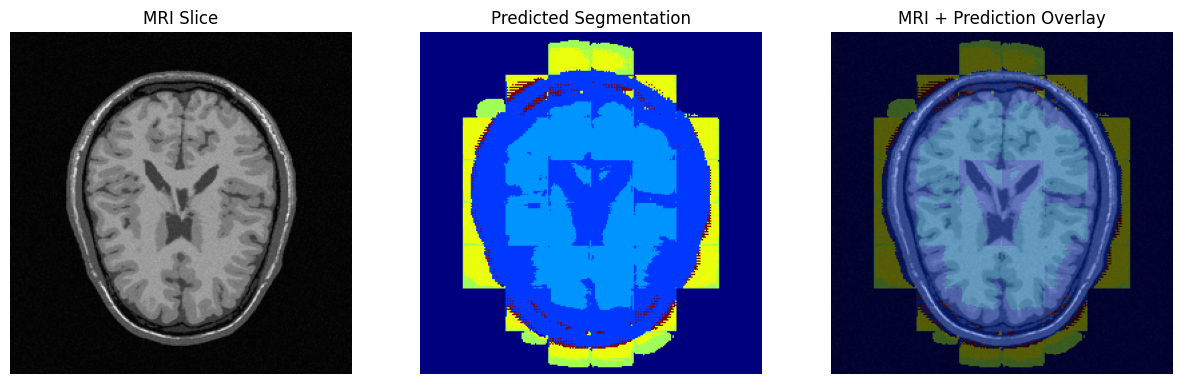


Inference Completed Successfully!

Sliding Window Prediction Workflow

Entire MRI Volume
↓
Extract 32³ Patch
↓
Predict Segmentation
↓
Move Sliding Window
↓
Predict Next Patch
↓
Combine Predictions
↓
Construct Full Brain Segmentation


3D Brain Segmentation Completed!


In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice =", DEVICE)

# ============================================================
# SET MODEL TO EVALUATION MODE
# ============================================================

model.eval()

# ============================================================
# PATCH PARAMETERS
# ============================================================

PATCH_SIZE = 32

STRIDE = 32

NUM_CLASSES = 12

# ============================================================
# USE ORIGINAL MRI VOLUME
# ============================================================

# Use normalized MRI volume
# Shape = [181,256,256]

DEPTH, HEIGHT, WIDTH = mri_volume.shape

print("\nMRI Volume Shape =",
      mri_volume.shape)

# ============================================================
# CREATE EMPTY PREDICTION VOLUME
# ============================================================

print("\nCreating Empty Prediction Volume...")

prediction_volume = np.zeros(
    (
        NUM_CLASSES,
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

# ------------------------------------------------------------
# COUNT VOLUME
# ------------------------------------------------------------

count_volume = np.zeros(
    (
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

# ============================================================
# SLIDING WINDOW INFERENCE
# ============================================================

print("\nStarting Sliding Window Inference...")

patch_count = 0

with torch.no_grad():

    for z in range(
        0,
        DEPTH - PATCH_SIZE + 1,
        STRIDE
    ):

        for y in range(
            0,
            HEIGHT - PATCH_SIZE + 1,
            STRIDE
        ):

            for x in range(
                0,
                WIDTH - PATCH_SIZE + 1,
                STRIDE
            ):

                # --------------------------------------------
                # EXTRACT PATCH
                # --------------------------------------------

                patch = mri_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                # --------------------------------------------
                # SKIP EMPTY PATCHES
                # --------------------------------------------

                if np.sum(patch) < 50:

                    continue

                # --------------------------------------------
                # CONVERT TO TENSOR
                # --------------------------------------------

                patch_tensor = torch.tensor(
                    patch,
                    dtype=torch.float32
                )

                # Add Batch Dimension
                patch_tensor = patch_tensor.unsqueeze(0)

                # Add Channel Dimension
                patch_tensor = patch_tensor.unsqueeze(0)

                # Final Shape:
                # [1,1,32,32,32]

                patch_tensor = patch_tensor.to(DEVICE)

                # --------------------------------------------
                # MODEL PREDICTION
                # --------------------------------------------

                outputs = model(
                    patch_tensor
                )

                # --------------------------------------------
                # SOFTMAX PROBABILITIES
                # --------------------------------------------

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

                probabilities = probabilities.cpu().numpy()[0]

                # --------------------------------------------
                # STORE PREDICTIONS
                # --------------------------------------------

                prediction_volume[
                    :,
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += probabilities

                # --------------------------------------------
                # UPDATE COUNT VOLUME
                # --------------------------------------------

                count_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += 1

                patch_count += 1

                print(
                    f"Processed Patch {patch_count}"
                )

# ============================================================
# TOTAL PATCHES
# ============================================================

print("\nTotal Predicted Patches =",
      patch_count)

# ============================================================
# AVERAGE OVERLAPPING PREDICTIONS
# ============================================================

print("\nAveraging Overlapping Predictions...")

prediction_volume = prediction_volume / (
    count_volume[np.newaxis, ...] + 1e-8
)

print("\nFinal Prediction Volume Shape =",
      prediction_volume.shape)

# ============================================================
# CONVERT PROBABILITIES TO LABELS
# ============================================================

print("\nConverting Probabilities To Labels...")

final_segmentation = np.argmax(
    prediction_volume,
    axis=0
)

print("\nFinal Segmentation Shape =",
      final_segmentation.shape)

# ============================================================
# UNIQUE LABELS
# ============================================================

print("\nUnique Predicted Labels")

print(np.unique(final_segmentation))

# ============================================================
# VISUALIZATION
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(15,5))

# ------------------------------------------------------------
# MRI
# ------------------------------------------------------------

plt.subplot(1,3,1)

plt.imshow(
    mri_volume[slice_index],
    cmap='gray'
)

plt.title("MRI Slice")

plt.axis("off")

# ------------------------------------------------------------
# SEGMENTATION
# ------------------------------------------------------------

plt.subplot(1,3,2)

plt.imshow(
    final_segmentation[slice_index],
    cmap='jet'
)

plt.title("Predicted Segmentation")

plt.axis("off")

# ------------------------------------------------------------
# OVERLAY
# ------------------------------------------------------------

plt.subplot(1,3,3)

plt.imshow(
    mri_volume[slice_index],
    cmap='gray'
)

plt.imshow(
    final_segmentation[slice_index],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Prediction Overlay")

plt.axis("off")

plt.show()

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nInference Completed Successfully!")

print("\nSliding Window Prediction Workflow")

print("""
Entire MRI Volume
↓
Extract 32³ Patch
↓
Predict Segmentation
↓
Move Sliding Window
↓
Predict Next Patch
↓
Combine Predictions
↓
Construct Full Brain Segmentation
""")

print("\n3D Brain Segmentation Completed!")